# Hyperparameter Tuning — EX15 FleetBrokenGlobal

Sequential tuning notebook. Each phase has a **lock-in cell** — set that value before running the next phase.

| Phase | Parameter | Evaluated via |
|-------|-----------|---------------|
| 1 | Learning rate α | Training convergence curves (VFA-only) |
| 2 | Discount factor γ | Training convergence curves (VFA-only) |
| 3 | Reward weights (ws, wc) | Train + full RA evaluation |
| 4 | Rollout: H, S, R | Full RA evaluation, coordinate descent |

> **Note on Phases 1–2:** Training curves (SL + weight stability) are sufficient for α and γ selection.
> This is consistent with how the feature ablation was conducted and avoids 5×3 = 15 expensive RA runs.
> Run one validation RA evaluation after locking both α and γ before moving to Phase 3.

In [27]:
import os, sys, re, shutil, tempfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "fomosim_matplotlib"))

# ── Workspace root ────────────────────────────────────────────────────────
WORKSPACE_ROOT = Path.cwd()
while WORKSPACE_ROOT.name != "FOMOsim" and WORKSPACE_ROOT.parent != WORKSPACE_ROOT:
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent

# ── LaTeX styling (mirrors plot_ablation_study.py) ────────────────────────
if shutil.which("latex"):
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage[T1]{fontenc} \usepackage{mlmodern}",
    })
else:
    plt.rcParams.update({"text.usetex": False, "font.family": "serif"})

# Adjust these to taste
TITLE_FONTSIZE  = 13
AXIS_FONTSIZE   = 12
LEGEND_FONTSIZE = 9
PLOT_DPI        = 150

COLORS = [
    "#344E41", "#D1495B", "#526ECA", "#EDAE49", "#84A579",
    "#7B3F5E", "#4A90A4", "#C67C3E", "#3D7068", "#A44A3F",
]

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
print(f"Workspace: {WORKSPACE_ROOT}")

Workspace: /Users/ingvildvs/FOMOsim


In [28]:
# ── Helpers: parse folder names produced by run_ablation_study.py ─────────
_FOLDER_RE    = re.compile(r"^(.+)_(?:alpha|adam|sgd)_([0-9]+(?:\.[0-9]+)?)(?:_(.*))?$")
_TIMESTAMP_RE = re.compile(r"(?:^|_)\d{8}_\d{6}(?:\s+copy)?$")
_GAMMA_RE     = re.compile(r"(?:^|_)g([0-9]+p[0-9]+)(?:_|$)")  # suffix starts with g (no leading _)
_WS_RE        = re.compile(r"_ws(m?[0-9]+p[0-9]+)(?:_|$)")
_WC_RE        = re.compile(r"_wc(m?[0-9]+p[0-9]+)(?:_|$)")

def _token_to_float(t: str) -> float:
    return float(t.replace("p", ".").replace("m", "-"))

_META_COLS = {
    "episode", "service_level", "alpha", "alpha_initial", "epsilon",
    "epsilon_initial", "starvations", "gamma", "transition_update_interval",
    "transition_batch_updates", "remainder_batch_updates",
    "batch_updates_this_episode", "long_congestions", "short_congestions",
    "total_trips", "bike_departures", "bike_arrivals", "total_onsite_repairs",
    "total_depot_pickups", "total_depot_deliveries", "total_depot_visits",
    "total_functional_pickups", "total_functional_deliveries",
    "broken_ratio_start_onsite", "broken_ratio_start_depot",
    "functional_ratio_start", "broken_ratio_end_onsite",
    "broken_ratio_end_depot", "functional_ratio_end",
    "new_breakdowns_onsite", "new_breakdowns_depot",
    "restored_onsite", "restored_depot",
}


def load_training_runs(study_dir, *, group_by: str = "alpha", smooth_window: int = 30):
    """
    Scan study_dir for weights_evolution CSVs.
    group_by: 'alpha' | 'gamma' | 'reward'
    Returns dict[key → list[run_dict]]
    """
    study_dir = Path(study_dir) if Path(str(study_dir)).is_absolute() else WORKSPACE_ROOT / study_dir
    groups = defaultdict(list)

    for folder in sorted(study_dir.iterdir()):
        if not folder.is_dir():
            continue
        m = _FOLDER_RE.match(folder.name)
        if not m:
            continue
        base, alpha, suffix = m.group(1), m.group(2), m.group(3) or ""
        suffix = _TIMESTAMP_RE.sub("", suffix).strip("_")

        if group_by == "alpha":
            key = alpha
        elif group_by == "gamma":
            gm = _GAMMA_RE.search(suffix)
            key = gm.group(1) if gm else alpha
        elif group_by == "reward":
            ws = _WS_RE.search(suffix)
            wc = _WC_RE.search(suffix)
            key = (f"ws={_token_to_float(ws.group(1)):+.1f}, wc={_token_to_float(wc.group(1)):+.1f}"
                   if ws and wc else "default")
        else:
            key = folder.name

        for csv in sorted(folder.glob("*_weights_evolution.csv")):
            sm = re.search(r"seed(\d+)", csv.name)
            seed = sm.group(1) if sm else "?"
            df = pd.read_csv(csv)
            if "episode" not in df.columns or "service_level" not in df.columns:
                continue
            df["episode"]       = pd.to_numeric(df["episode"],       errors="coerce")
            df["service_level"] = pd.to_numeric(df["service_level"], errors="coerce")
            df = df.dropna(subset=["episode", "service_level"])
            if df.empty:
                continue
            w_cols = [c for c in df.columns if c not in _META_COLS]
            w_df   = df[w_cols].apply(pd.to_numeric, errors="coerce")
            sl_sm  = pd.Series(df["service_level"].values).rolling(smooth_window, min_periods=1).mean().values
            groups[key].append({
                "seed": seed, "folder": folder.name, "alpha": alpha,
                "episodes": df["episode"].values,
                "sl_raw": df["service_level"].values, "sl": sl_sm,
                "weights": w_df.values, "features": w_cols,
            })

    return dict(groups)


def _conv_metrics(sl: np.ndarray, last_n: int = 30) -> dict:
    peak  = float(np.max(sl))
    final = float(np.mean(sl[-last_n:]))
    std   = float(np.std(sl[-last_n:]))
    thr   = 0.95 * peak
    conv  = next((i for i in range(len(sl) - 10) if np.all(sl[i:i+10] >= thr)), None)
    return {"peak": peak, "final": final, "std": std, "conv_ep": conv}


def plot_sl_comparison(groups: dict, title: str, param_label: str = r"$\alpha$",
                       last_n: int = 30, figsize=(12, 6)) -> plt.Figure:
    """SL convergence: one line per group (mean ± 1 std across seeds)."""
    fig, ax = plt.subplots(figsize=figsize)
    cmap = {k: COLORS[i % len(COLORS)] for i, k in enumerate(sorted(groups))}

    for key in sorted(groups):
        runs = groups[key]
        if not runs:
            continue
        n = min(len(r["sl"]) for r in runs)
        sls  = np.array([r["sl"][:n] for r in runs])
        eps  = runs[0]["episodes"][:n]
        mean = sls.mean(axis=0)
        std  = sls.std(axis=0)
        col  = cmap[key]
        try:
            v = float(key.replace("p", ".").replace("m", "-")) if "p" in key else float(key)
            lbl = rf"{param_label}$={v:g}$  (peak={mean.max():.4f}, final={mean[-last_n:].mean():.4f})"
        except ValueError:
            lbl = rf"{param_label}$={key}$  (peak={mean.max():.4f}, final={mean[-last_n:].mean():.4f})"

        ax.plot(eps, mean, linewidth=2.0, color=col, alpha=0.85, label=lbl)
        ax.fill_between(eps, mean - std, mean + std, color=col, alpha=0.12)
        trend = np.poly1d(np.polyfit(eps, mean, 1))(eps)
        ax.plot(eps, trend, linestyle="--", linewidth=2.0, color=col, alpha=0.35)

    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("Training episode", fontsize=AXIS_FONTSIZE)
    ax.set_ylabel(r"Service level (30-ep moving avg)", fontsize=AXIS_FONTSIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEGEND_FONTSIZE, frameon=True)
    plt.tight_layout()
    return fig


def plot_norm_evolution(groups: dict, title: str, param_label: str = r"$\alpha$",
                        figsize=(12, 5)) -> plt.Figure:
    """Plot ||θ||₂ per episode for all groups (mean ± 1 std across seeds)."""
    fig, ax = plt.subplots(figsize=figsize)
    cmap = {k: COLORS[i % len(COLORS)] for i, k in enumerate(sorted(groups))}

    for key in sorted(groups):
        runs = groups[key]
        if not runs:
            continue
        n     = min(len(r["weights"]) for r in runs)
        norms = np.array([np.linalg.norm(r["weights"][:n], axis=1) for r in runs])
        eps   = runs[0]["episodes"][:n]
        mean  = norms.mean(axis=0)
        std   = norms.std(axis=0)
        col   = cmap[key]
        try:
            v = float(key.replace("p", ".").replace("m", "-")) if "p" in key else float(key)
            lbl = rf"{param_label}$={v:g}$  (final={mean[-1]:.3f})"
        except ValueError:
            lbl = rf"{param_label}$={key}$  (final={mean[-1]:.3f})"

        ax.plot(eps, mean, linewidth=2.0, color=col, alpha=0.85, label=lbl)
        ax.fill_between(eps, mean - std, mean + std, color=col, alpha=0.12)

    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("Training episode", fontsize=AXIS_FONTSIZE)
    ax.set_ylabel(r"$\|\theta\|_2$", fontsize=AXIS_FONTSIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEGEND_FONTSIZE, frameon=True)
    plt.tight_layout()
    return fig


def plot_weight_evolution(runs: list, title: str, figsize=(12, 5)) -> plt.Figure:
    """Mean weight trajectories across seeds for one group."""
    if not runs:
        return None
    n    = min(len(r["weights"]) for r in runs)
    feat = runs[0]["features"]
    W    = np.nanmean(np.array([r["weights"][:n, :len(feat)] for r in runs], dtype=float), axis=0)
    eps  = runs[0]["episodes"][:n]

    fig, ax = plt.subplots(figsize=figsize)
    for i, f in enumerate(feat):
        ax.plot(eps, W[:, i], linewidth=2.0, alpha=0.85,
                color=COLORS[i % len(COLORS)], label=f"{f} ({W[-1, i]:+.3f})")
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.4)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_xlabel("Episode", fontsize=AXIS_FONTSIZE)
    ax.set_ylabel(r"Weight ($\theta$)", fontsize=AXIS_FONTSIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
    plt.tight_layout()
    return fig


def convergence_table(groups: dict, param_name: str = "alpha", last_n: int = 30):
    """Styled convergence table with SL metrics, final weight norm, and Δθ convergence metric."""
    rows = []
    for key in sorted(groups):
        runs = groups[key]
        if not runs:
            continue
        n    = min(len(r["sl"]) for r in runs)
        sls  = np.array([r["sl"][:n] for r in runs])
        mean = sls.mean(axis=0)
        m = _conv_metrics(mean, last_n)

        seed_norms = []
        seed_rel_steps = []
        for r in runs:
            w = r["weights"]
            tail = w[-last_n:] if len(w) >= last_n else w
            theta_bar = np.nanmean(tail, axis=0)
            norm_tail = float(np.linalg.norm(theta_bar))
            seed_norms.append(norm_tail)
            if len(tail) >= 2 and norm_tail > 0:
                deltas = np.linalg.norm(np.diff(tail.astype(float), axis=0), axis=1)
                seed_rel_steps.append(float(np.mean(deltas)) / norm_tail * 100)

        rows.append({
            param_name:                  key,
            "N seeds":                   len(runs),
            "Peak SL":                   m["peak"],
            "Final SL (mean)":           m["final"],
            "Convergence ep.":           m["conv_ep"] if m["conv_ep"] is not None else ">300",
            r"Final $\|\theta\|$":       float(np.mean(seed_norms)),
            r"Rel. $\Delta\theta$ (%)": float(np.nanmean(seed_rel_steps)) if seed_rel_steps else float("nan"),
        })
    df = pd.DataFrame(rows).set_index(param_name)
    return (
        df.style
          .format({"Peak SL": "{:.4f}", "Final SL (mean)": "{:.4f}",
                   r"Final $\|\theta\|$": "{:.3f}",
                   r"Rel. $\Delta\theta$ (%)": "{:.2f}"})
          .background_gradient(subset=["Final SL (mean)"], cmap="Blues")
          .background_gradient(subset=[r"Final $\|\theta\|$"], cmap="Oranges")
          .background_gradient(subset=[r"Rel. $\Delta\theta$ (%)"], cmap="Greens_r")
          .set_caption(f"Convergence metrics grouped by {param_name}")
    )

print("Training helpers loaded.")

Training helpers loaded.


In [29]:
# -- Helpers: evaluation results (results.csv from run_logs/) ------

EVAL_METRIC_LABELS = {
    "service_level":          r"Service level",
    "starvations":            r"Starvations",
    "congestions":            r"Congestions",
    "functional_ratio_end":   r"Func. ratio end (FR)",
    "maintenance_pct":        r"Maintenance action %",
    "total_depot_visits":     r"Depot visits",
    "avg_decision_runtime_s": r"Decision time mean (s)",
    "p95_decision_runtime_s": r"Decision time p95 (s)",
    "max_decision_runtime_s": r"Decision time max (s)",
    "n_decisions":            r"Decision count",
}

# Short display names -- edit to rename labels in all plots/tables
LABEL_DISPLAY: dict[str, str] = {}   # e.g. {'Hybrid: EX15_...': 'H60 S5 R5'}

def _disp(label: str) -> str:
    return LABEL_DISPLAY.get(label, label.replace('_', ' '))

def _strip_suffix(name: str) -> str:
    name = re.sub(r"_seed\d+.*$", "", name)
    name = re.sub(r"_TD_W\d+.*$", "", name)
    name = re.sub(r"_OS_W\d+.*$", "", name)
    return name.strip('_')

def _label_from_path(csv_path: Path) -> str:
    folder = csv_path.parent.name
    if folder.startswith("Hybrid_") or folder.startswith("hybrid_"):
        return "Hybrid: " + _strip_suffix(re.sub(r"^[Hh]ybrid_", "", folder))
    if folder.startswith("VFA_") or folder.startswith("vfa_"):
        return "VFA: "    + _strip_suffix(re.sub(r"^[Vv][Ff][Aa]_", "", folder))
    if "greedy" in folder.lower():  return "Greedy maintenance"
    if "nothing" in folder.lower(): return "Do nothing"
    return folder

def _decision_runtime_stats(run_dir: Path, seed) -> dict:
    if pd.isna(seed):
        return {}
    seed_str = str(int(seed)) if isinstance(seed, (int, float, np.integer, np.floating)) else str(seed)
    candidates = [
        run_dir / f"seed_{seed_str}" / "decisions.csv",
        run_dir / seed_str / "decisions.csv",
        run_dir / "decisions.csv",
    ]
    matches = [c for c in candidates if c.exists()]
    if not matches:
        matches = sorted(run_dir.rglob(f"seed_{seed_str}/decisions.csv"))
    if not matches:
        return {}
    try:
        dec = pd.read_csv(matches[0], usecols=["decision_runtime_s"])
    except Exception as e:
        print(f"Warning: {matches[0]}: {e}")
        return {}
    runtime = pd.to_numeric(dec["decision_runtime_s"], errors="coerce").dropna()
    return {} if runtime.empty else {
        "avg_decision_runtime_s": float(runtime.mean()),
        "p95_decision_runtime_s": float(runtime.quantile(0.95)),
        "max_decision_runtime_s": float(runtime.max()),
        "n_decisions":            int(runtime.count()),
    }

def _attach_decision_runtime(df: pd.DataFrame, run_dir: Path) -> pd.DataFrame:
    df = df.copy()
    for col in ["avg_decision_runtime_s", "p95_decision_runtime_s",
                "max_decision_runtime_s", "n_decisions"]:
        df[col] = np.nan
    if "seed" not in df.columns:
        return df
    for idx, seed in df["seed"].items():
        for k, v in _decision_runtime_stats(run_dir, seed).items():
            df.loc[idx, k] = v
    return df

def load_eval_results(run_log_dirs: list, label_override: dict | None = None) -> pd.DataFrame:
    """Load results.csv files from a list of run_log paths."""
    rows = []
    for raw in run_log_dirs:
        path = Path(raw) if Path(str(raw)).is_absolute() else WORKSPACE_ROOT / raw
        csv_files = ([path] if path.is_file() and path.name == "results.csv"
                     else sorted(path.rglob("results.csv")) if path.is_dir()
                     else [])
        if not csv_files:
            print(f"Warning: no results.csv found at {raw}")
        for csv_path in csv_files:
            lbl = (label_override or {}).get(str(raw)) or _label_from_path(csv_path)
            try:
                df = pd.read_csv(csv_path)
            except Exception as e:
                print(f"Warning: {csv_path}: {e}"); continue
            df = _attach_decision_runtime(df, csv_path.parent)
            df["label"]  = lbl
            df["source"] = str(csv_path.relative_to(WORKSPACE_ROOT))
            rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def _add_derived(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    maint = df.get("total_fixed_on_site", 0).fillna(0) + df.get("total_picked_up_to_depot", 0).fillna(0)
    reb   = df.get("total_functional_pickups", 0).fillna(0) + df.get("total_functional_deliveries", 0).fillna(0)
    df["maintenance_pct"] = np.where((maint + reb) > 0, maint / (maint + reb), np.nan)
    return df

def _ordered_labels(df: pd.DataFrame, sort_by: str = "service_level") -> list:
    if sort_by in df.columns:
        return df.groupby("label")[sort_by].mean().sort_values(ascending=False).index.tolist()
    return sorted(df["label"].unique().tolist())


def plot_starv_cong_grouped(df: pd.DataFrame, sort_by: str = "service_level",
                             title: str = "Starvations and congestions by experiment",
                             figsize=None) -> plt.Figure:
    """Grouped vertical bar chart: starvations (red) and congestions (blue) per label,
    sorted by sort_by (best first). Error bars = 1 std across seeds."""
    df = _add_derived(df)
    if not {"starvations", "congestions"}.issubset(df.columns):
        print("Missing starvations or congestions column."); return None

    order  = _ordered_labels(df, sort_by)
    xlbls  = [_disp(l) for l in order]
    x, w   = np.arange(len(order)), 0.35
    ekw    = {"linewidth": 1.2, "capsize": 4}

    sm = np.array([df[df["label"] == l]["starvations"].mean() for l in order])
    ss = np.array([df[df["label"] == l]["starvations"].std(ddof=0) for l in order])
    cm = np.array([df[df["label"] == l]["congestions"].mean() for l in order])
    cs = np.array([df[df["label"] == l]["congestions"].std(ddof=0) for l in order])

    fig, ax = plt.subplots(figsize=figsize or (max(7, 1.8 * len(order)), 6))
    b1 = ax.bar(x - w/2, sm, w, yerr=ss, color=COLORS[1], alpha=0.85, label="Starvations", **ekw)
    b2 = ax.bar(x + w/2, cm, w, yerr=cs, color=COLORS[2], alpha=0.85, label="Congestions", **ekw)

    for bars, means in [(b1, sm), (b2, cm)]:
        for bar, val in zip(bars, means):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() * 1.02,
                        f"{val:.0f}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("Count (mean)", fontsize=AXIS_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.legend(fontsize=LEGEND_FONTSIZE)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    return fig


def plot_sl_fr_grouped(df: pd.DataFrame, sort_by: str = "service_level",
                        title: str = "Service level and functional ratio end by experiment",
                        figsize=None) -> plt.Figure:
    """Grouped vertical bar chart: service level (dark green) and FR end (gold) per label.
    Y-axis zoomed to data range so small differences are visible. Error bars = 1 std."""
    df = _add_derived(df)
    metrics = [m for m in ["service_level", "functional_ratio_end"] if m in df.columns]
    if not metrics:
        print("Missing service_level and functional_ratio_end columns."); return None

    order  = _ordered_labels(df, sort_by)
    xlbls  = [_disp(l) for l in order]
    x, w   = np.arange(len(order)), 0.35
    offsets    = [-w/2, w/2]
    bar_colors = [COLORS[0], COLORS[3]]
    metric_names = {"service_level": "Service level", "functional_ratio_end": "FR end"}
    ekw = {"linewidth": 1.2, "capsize": 4}

    fig, ax = plt.subplots(figsize=figsize or (max(7, 1.8 * len(order)), 6))
    all_vals = []
    for i, m in enumerate(metrics):
        means = np.array([df[df["label"] == l][m].mean() for l in order])
        stds  = np.array([df[df["label"] == l][m].std(ddof=0) for l in order])
        all_vals.extend(means[~np.isnan(means)].tolist())
        bars = ax.bar(x + offsets[i], means, w, yerr=stds,
                      color=bar_colors[i], alpha=0.85,
                      label=metric_names.get(m, m), **ekw)
        for bar, val in zip(bars, means):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.0005,
                        f"{val:.4f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("Value (mean)", fontsize=AXIS_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.legend(fontsize=LEGEND_FONTSIZE)
    ax.grid(axis="y", alpha=0.3)
    if all_vals:
        span = max(all_vals) - min(all_vals)
        pad  = max(span * 0.5, 0.003)
        ax.set_ylim(max(0, min(all_vals) - pad), min(1.0, max(all_vals) + pad * 1.5))
    plt.tight_layout()
    return fig


def eval_summary_table(df: pd.DataFrame, metrics: list, sort_by: str = "service_level"):
    """Styled wide table: mean +/- std per label x metric, sorted by sort_by."""
    df = _add_derived(df)
    metrics = [m for m in metrics if m in df.columns]
    rows = []
    for lbl, grp in df.groupby("label"):
        row = {"Label": _disp(lbl), "N": int(len(grp))}
        for m in metrics:
            row[f"{m}_mean"] = grp[m].mean()
            row[f"{m}_std"]  = grp[m].std()
        rows.append(row)
    out = pd.DataFrame(rows).set_index("Label")
    if f"{sort_by}_mean" in out.columns:
        out = out.sort_values(f"{sort_by}_mean", ascending=False)
    fmt, rename = {}, {}
    for m in metrics:
        lbl_m = EVAL_METRIC_LABELS.get(m, m.replace("_", " ").title())
        rename[f"{m}_mean"] = f"{lbl_m} (mean)"
        rename[f"{m}_std"]  = f"{lbl_m} (std)"
        if m in ("service_level", "functional_ratio_end", "maintenance_pct"):
            fmt[f"{m}_mean"] = "{:.4f}"; fmt[f"{m}_std"] = "{:.4f}"
        elif m.endswith("_runtime_s"):
            fmt[f"{m}_mean"] = "{:.4f}"; fmt[f"{m}_std"] = "{:.4f}"
        else:
            fmt[f"{m}_mean"] = "{:.1f}";  fmt[f"{m}_std"] = "{:.1f}"
    cols = [c for c in out.columns if c != "N"]
    return (
        out[cols].rename(columns=rename)
                 .style
                 .format({rename[k]: v for k, v in fmt.items() if k in rename})
                 .background_gradient(
                     subset=[rename.get(f"{sort_by}_mean", f"{sort_by}_mean")],
                     cmap="Blues")
                 .set_caption("Evaluation summary (mean +/- std across seeds)")
    )



def load_decisions_data(run_log_dirs: list, label_override: dict | None = None) -> pd.DataFrame:
    """Load decisions.csv files for hourly maintenance profile analysis."""
    WANTED = {"day", "hour", "onsite_repairs", "depot_pickups",
              "depot_deliveries", "load_from_queue",
              "functional_pickups", "functional_deliveries",
              "is_at_depot", "selected_action_is_maintenance",
              "maintenance_flag_present"}
    rows = []
    for raw in run_log_dirs:
        path = Path(raw) if Path(str(raw)).is_absolute() else WORKSPACE_ROOT / raw
        if not path.is_dir():
            continue
        lbl = (label_override or {}).get(str(raw), str(raw))
        for dec_path in sorted(path.rglob("decisions.csv")):
            try:
                header_cols = pd.read_csv(dec_path, nrows=0).columns.tolist()
                cols = [c for c in header_cols if c in WANTED]
                dec = pd.read_csv(dec_path, usecols=cols)
            except Exception as e:
                print(f"Warning: {dec_path}: {e}"); continue
            sm = re.search(r"\d+$", dec_path.parent.name)  # use seed dir name, not full path
            dec["seed_file"] = int(sm.group()) if sm else 0
            dec["label"] = lbl
            rows.append(dec)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def plot_maintenance_grid(df: pd.DataFrame, df_dec: pd.DataFrame | None = None,
                          sort_by: str = "service_level",
                          title: str = "Maintenance analysis",
                          figsize=(14, 10)) -> plt.Figure:
    """
    2x2 maintenance grid:
      (0,0) Onsite repairs vs depot pickups
      (0,1) Decision type breakdown: % maintenance vs rebalancing (100% stacked)
      (1,0) Hourly maintenance profile (solid=onsite, dashed=depot)
      (1,1) Turnover: new breakdowns vs restored
    """
    df = _add_derived(df)
    order = _ordered_labels(df, sort_by)
    xlbls = [_disp(l) for l in order]
    x = np.arange(len(order))
    w, ekw = 0.35, {"linewidth": 1.0, "capsize": 3}

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(title, fontsize=TITLE_FONTSIZE, fontweight="bold")

    def _ms(col):
        m = np.array([df[df["label"] == l][col].mean() if col in df.columns else np.nan for l in order])
        s = np.array([df[df["label"] == l][col].std(ddof=0) if col in df.columns else 0.0 for l in order])
        return m, s

    def _bar_lbl(ax, bars, vals):
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                        f"{v:.0f}", ha="center", va="bottom", fontsize=8)

    # (0,0) Onsite repairs vs depot pickups
    ax = axes[0, 0]
    om, os_ = _ms("total_fixed_on_site")
    dm, ds  = _ms("total_picked_up_to_depot")
    b1 = ax.bar(x - w/2, om, w, yerr=os_, color=COLORS[3], alpha=0.85, label="Onsite repairs", **ekw)
    b2 = ax.bar(x + w/2, dm, w, yerr=ds,  color=COLORS[4], alpha=0.85, label="Depot pickups",  **ekw)
    _bar_lbl(ax, b1, om); _bar_lbl(ax, b2, dm)
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=8)
    ax.set_title("Onsite repairs vs depot pickups", fontsize=10)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3); ax.set_ylim(bottom=0)

    # (0,1) 100% stacked bar — % maintenance vs rebalancing decisions
    # Uses selected_action_is_maintenance from decisions.csv (decision-count based).
    # Falls back to bike-count-based maintenance_pct from results.csv if unavailable.
    ax = axes[0, 1]
    if (df_dec is not None and not df_dec.empty
            and "selected_action_is_maintenance" in df_dec.columns):
        mp = np.array([
            df_dec[df_dec["label"] == l]["selected_action_is_maintenance"].mean() * 100
            for l in order
        ])
        src_note = "decisions.csv"
    else:
        mp = np.array([df[df["label"] == l]["maintenance_pct"].mean() * 100 for l in order])
        src_note = "results.csv (fallback)"
    rp = 100.0 - mp
    ax.bar(x, mp, color=COLORS[1], alpha=0.85, label="Maintenance")
    ax.bar(x, rp, bottom=mp, color=COLORS[2], alpha=0.85, label="Rebalancing")
    for i, (mv, rv) in enumerate(zip(mp, rp)):
        if mv > 4:
            ax.text(i, mv / 2, f"{mv:.1f}%", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
        if rv > 4:
            ax.text(i, mv + rv / 2, f"{rv:.1f}%", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=8)
    ax.set_ylim(0, 100); ax.set_ylabel("%", fontsize=9)
    ax.set_title(f"Decision type breakdown, %, {src_note}", fontsize=10)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

    # (1,0) Hourly maintenance profile
    ax = axes[1, 0]
    if df_dec is not None and not df_dec.empty and "hour" in df_dec.columns:
        hours = list(range(24))
        for i, lbl in enumerate(order):
            sub = df_dec[df_dec["label"] == lbl]
            if sub.empty:
                continue
            col = COLORS[i % len(COLORS)]
            for metric, ls, sfx in [("onsite_repairs", "-",  " onsite"),
                                     ("depot_pickups",  "--", " depot")]:
                if metric not in sub.columns:
                    continue
                prof = (sub.groupby(["seed_file", "day", "hour"])[metric]
                           .sum().groupby("hour").mean()
                           .reindex(hours, fill_value=0))
                ax.plot(hours, prof.values, color=col, linewidth=1.8,
                        linestyle=ls, alpha=0.85,
                        label=f"{_disp(lbl)}{sfx}")
        ax.set_xlabel("Hour of day", fontsize=9)
        ax.set_ylabel("Avg. actions per day", fontsize=9)
        ax.set_xticks(range(0, 24, 2))
        ax.legend(fontsize=6, loc="upper right", ncol=2)
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No decisions data.\nCall load_decisions_data()\nand pass as df_dec.",
                ha="center", va="center", transform=ax.transAxes, fontsize=9, color="grey")
        ax.set_axis_off()
    ax.set_title("Hourly maintenance profile", fontsize=10)

    # (1,1) Turnover: new breakdowns vs restored
    ax = axes[1, 1]
    def _combined(c1, c2):
        m = np.array([
            (df[df["label"] == l][c1].mean() if c1 in df.columns else 0) +
            (df[df["label"] == l][c2].mean() if c2 in df.columns else 0)
            for l in order])
        s = np.array([
            np.sqrt((df[df["label"] == l][c1].std(ddof=0) if c1 in df.columns else 0)**2 +
                    (df[df["label"] == l][c2].std(ddof=0) if c2 in df.columns else 0)**2)
            for l in order])
        return m, s
    nm, ns = _combined("new_breakdowns_onsite", "new_breakdowns_depot")
    rm, rs = _combined("restored_onsite",       "restored_depot")
    b3 = ax.bar(x - w/2, nm, w, yerr=ns, color=COLORS[1], alpha=0.85, label="New breakdowns", **ekw)
    b4 = ax.bar(x + w/2, rm, w, yerr=rs, color=COLORS[0], alpha=0.85, label="Restored",       **ekw)
    _bar_lbl(ax, b3, nm); _bar_lbl(ax, b4, rm)
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=20, ha="right", fontsize=8)
    ax.set_title("Turnover: new breakdowns vs restored", fontsize=10)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3); ax.set_ylim(bottom=0)

    plt.tight_layout()
    return fig





def plot_hourly_decision_breakdown(df_dec: pd.DataFrame,
                                    df_results: pd.DataFrame | None = None,
                                    sort_by: str = "service_level",
                                    title: str = "Hourly decision breakdown",
                                    figsize=None) -> plt.Figure:
    """
    100% stacked bar chart per experiment, one subplot per label.
    Four categories derived from action columns (bottom to top):
      Pure maintenance  — only maintenance actions (onsite/depot), no functional moves
      Mixed             — both maintenance AND functional pickups/deliveries
      Pure rebalancing  — only functional pickups/deliveries, no maintenance
      Transit           — no bike interaction at all (positioning move)
    """
    needed = {"onsite_repairs", "depot_pickups", "functional_pickups",
              "functional_deliveries", "hour"}
    if df_dec is None or df_dec.empty or not needed.issubset(df_dec.columns):
        missing = needed - set(df_dec.columns) if df_dec is not None else needed
        print(f"Missing columns: {missing}"); return None

    order = (_ordered_labels(df_results, sort_by)
             if df_results is not None and not df_results.empty
             else sorted(df_dec["label"].unique().tolist()))
    order = [l for l in order if l in df_dec["label"].values]
    if not order:
        print("No matching labels."); return None

    op_hours = sorted(df_dec["hour"].unique())
    n_exp    = len(order)
    fig, axes = plt.subplots(1, n_exp,
                             figsize=figsize or (max(5, 4.5 * n_exp), 5),
                             sharey=True, squeeze=False)

    CATS = [
        ("pure_maint", COLORS[1],  "Pure maintenance"),
        ("mixed",      COLORS[3],  "Mixed (reb + maint)"),
        ("pure_reb",   COLORS[2],  "Pure rebalancing"),
        ("transit",    "#AAAAAA",  "Transit (no action)"),
    ]

    for col_idx, lbl in enumerate(order):
        ax   = axes[0, col_idx]
        sub  = df_dec[df_dec["label"] == lbl].copy()

        # Classify each decision from action columns
        maint_cols = [c for c in ["onsite_repairs", "depot_pickups",
                                  "depot_deliveries", "load_from_queue"]
                      if c in sub.columns]
        reb_cols   = [c for c in ["functional_pickups", "functional_deliveries"]
                      if c in sub.columns]
        has_m = (sub[maint_cols].fillna(0).sum(axis=1) > 0)
        has_r = (sub[reb_cols].fillna(0).sum(axis=1) > 0)

        sub["pure_maint"] = (has_m & ~has_r).astype(float)
        sub["mixed"]      = (has_m &  has_r).astype(float)
        sub["pure_reb"]   = (~has_m &  has_r).astype(float)
        sub["transit"]    = (~has_m & ~has_r).astype(float)

        def _frac(col):
            return (sub.groupby(["seed_file", "day", "hour"])[col]
                       .mean().groupby("hour").mean()
                       .reindex(op_hours, fill_value=0).values * 100)

        x       = np.arange(len(op_hours))
        bottoms = np.zeros(len(op_hours))
        for cat, color, label in CATS:
            frac = _frac(cat)
            ax.bar(x, frac, bottom=bottoms, color=color, alpha=0.88,
                   label=label if col_idx == 0 else "_nolegend_")
            for xi, (bot, val) in enumerate(zip(bottoms, frac)):
                if val > 8:
                    ax.text(xi, bot + val / 2, f"{val:.0f}%",
                            ha="center", va="center",
                            fontsize=7, color="white", fontweight="bold")
            bottoms += frac

        ax.set_xticks(x)
        ax.set_xticklabels([str(h) for h in op_hours], rotation=45, fontsize=8)
        ax.set_xlabel("Hour", fontsize=9)
        ax.set_title(_disp(lbl), fontsize=10, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel("%", fontsize=9)
        ax.set_ylim(0, 100)
        ax.grid(axis="y", alpha=0.3)

    handles, hlbls = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, hlbls, loc="lower center", ncol=4,
               fontsize=9, bbox_to_anchor=(0.5, -0.08), frameon=True)
    fig.suptitle(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    plt.tight_layout()
    return fig



print("Evaluation helpers loaded.")


Evaluation helpers loaded.


---
## Phase 1 — Learning Rate α

**Before running this section**, train EX15 with the candidate α values:

```bash
python policies/sjovik_sund/ablation_study/run_ablation_study.py \
  --experiments EX15_FleetBrokenGlobal \
  --alphas 0.005 0.01 0.05 0.1 0.5 \
  --seeds 1000 \
  --episodes 300 \
  --output_dir tuning/phase1_alpha \
  --gamma 0.97 \
  --weight_starvation -1.0 \
  --weight_congestion -1.0 \
  --weight_fleet_degradation 0.0 \
  --use_bias_feature \
  --initial_bias -2.5 \
  --transition_update_interval 100 \
  --use_terminal_update \
  --use_feature_scale_diagnostics \
  --diagnostic_every_n_episodes 25 \
  --epsilon_start 0.0 \
  --epsilon_end 0.0
```

In [30]:
# ── Phase 1 config ────────────────────────────────────────────────────────
PHASE1_DIR    = "models/tuning/phase1_alpha"   # output_dir passed to run_ablation_study
PHASE1_LAST_N = 30                             # episodes averaged for "final SL"

groups_alpha = load_training_runs(PHASE1_DIR, group_by="alpha", smooth_window=30)
print(f"Found {len(groups_alpha)} alpha group(s):")
for k, v in sorted(groups_alpha.items()):
    print(f"  \u03b1={k}: {len(v)} seed(s) \u2014 {[r['seed'] for r in v]}")

Found 5 alpha group(s):
  α=0.005: 1 seed(s) — ['1000']
  α=0.01: 1 seed(s) — ['1000']
  α=0.05: 1 seed(s) — ['1000']
  α=0.1: 1 seed(s) — ['1000']
  α=0.5: 1 seed(s) — ['1000']


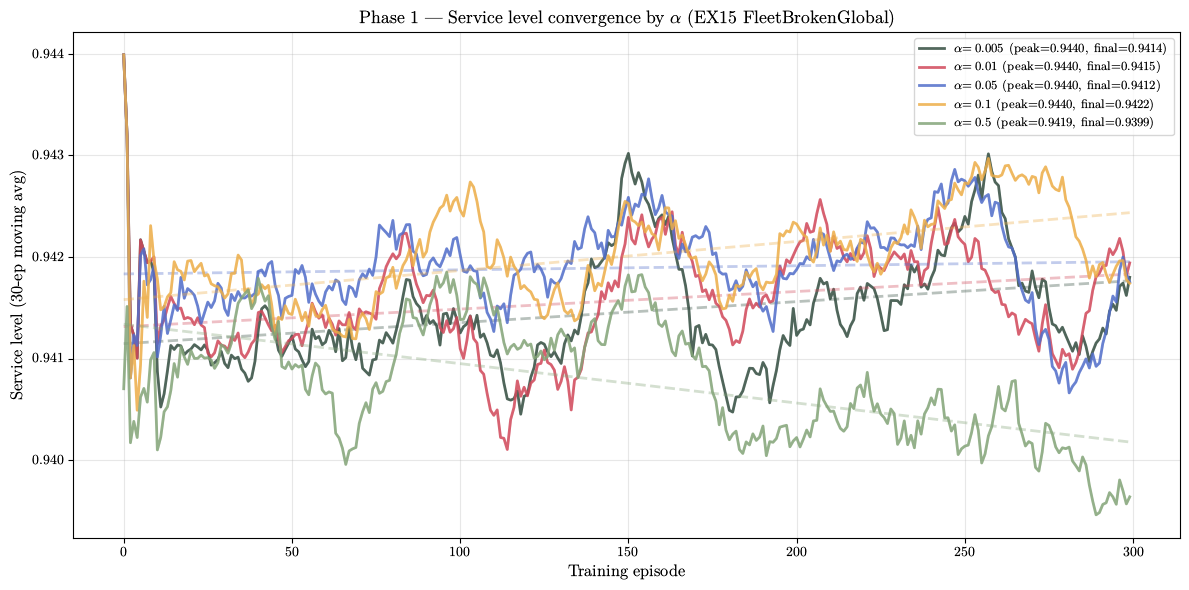

In [31]:
# ── Phase 1: SL convergence comparison ───────────────────────────────────
fig = plot_sl_comparison(
    groups_alpha,
    title=r"Phase 1 --- Service level convergence by $\alpha$ (EX15 FleetBrokenGlobal)",
    param_label=r"$\alpha$",
    last_n=PHASE1_LAST_N,
)
plt.show()

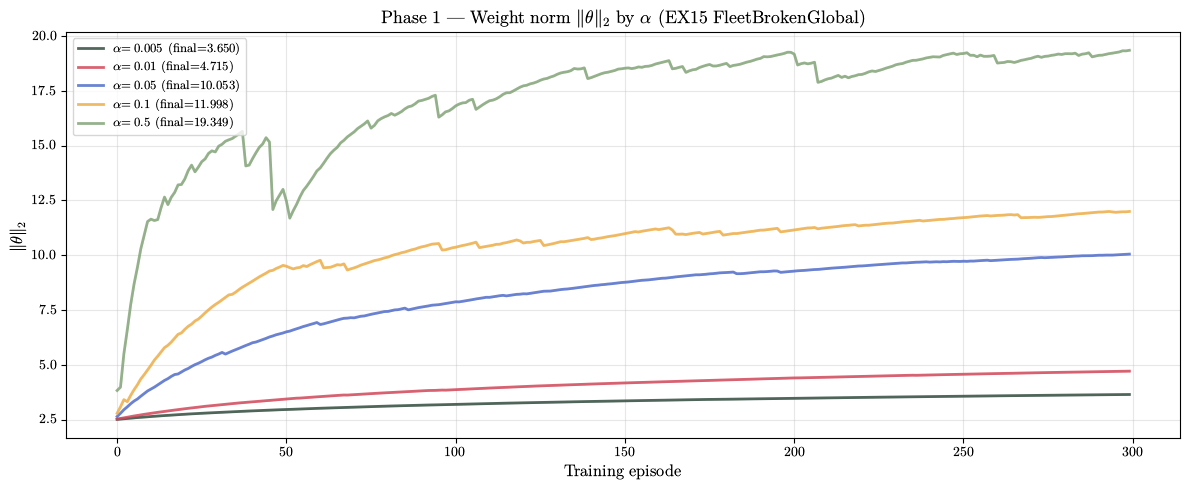

In [32]:
# ── Phase 1: Weight norm evolution ───────────────────────────────────────
fig = plot_norm_evolution(
    groups_alpha,
    title=r"Phase 1 --- Weight norm $\|\theta\|_2$ by $\alpha$ (EX15 FleetBrokenGlobal)",
    param_label=r"$\alpha$",
)
plt.show()

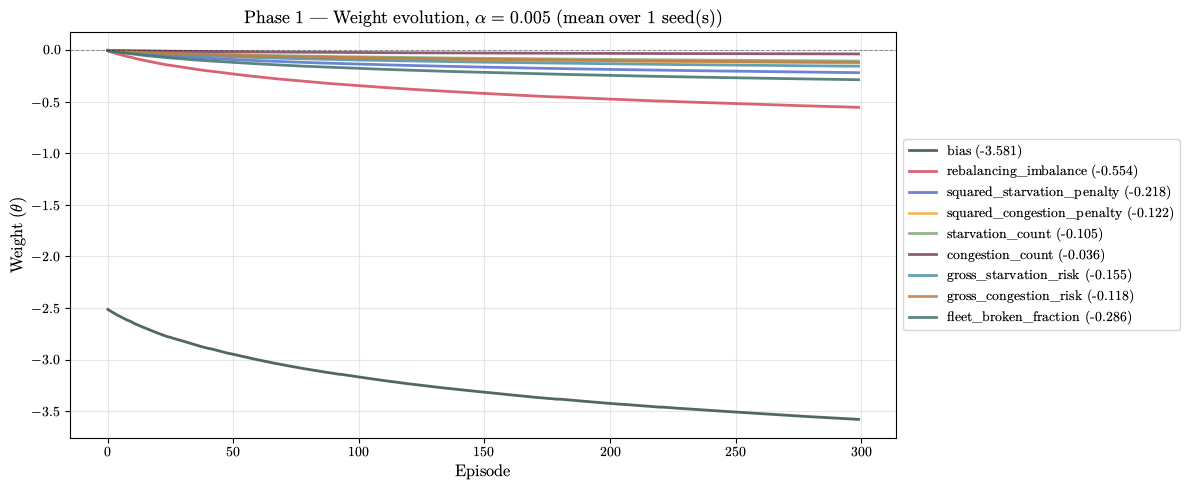

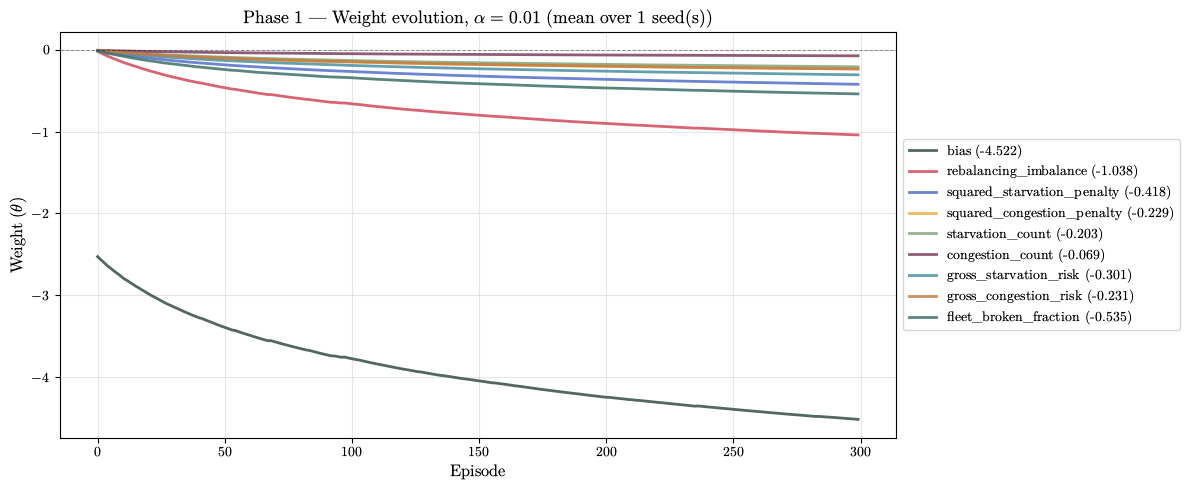

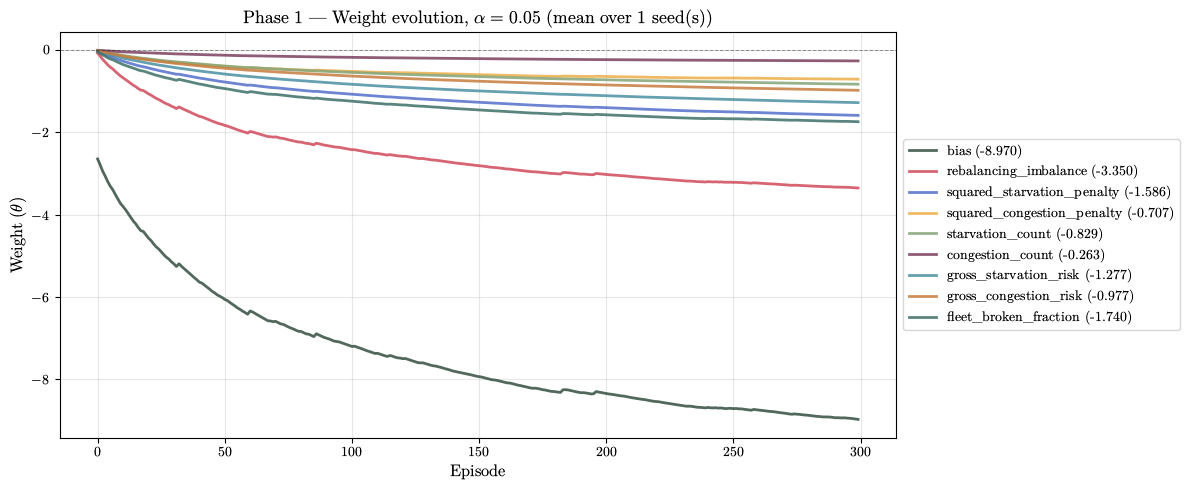

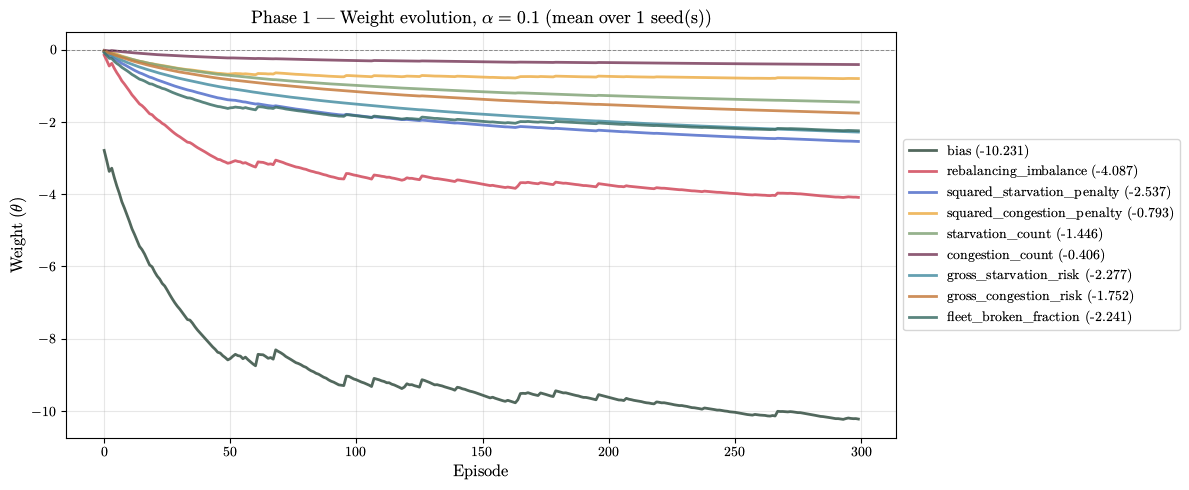

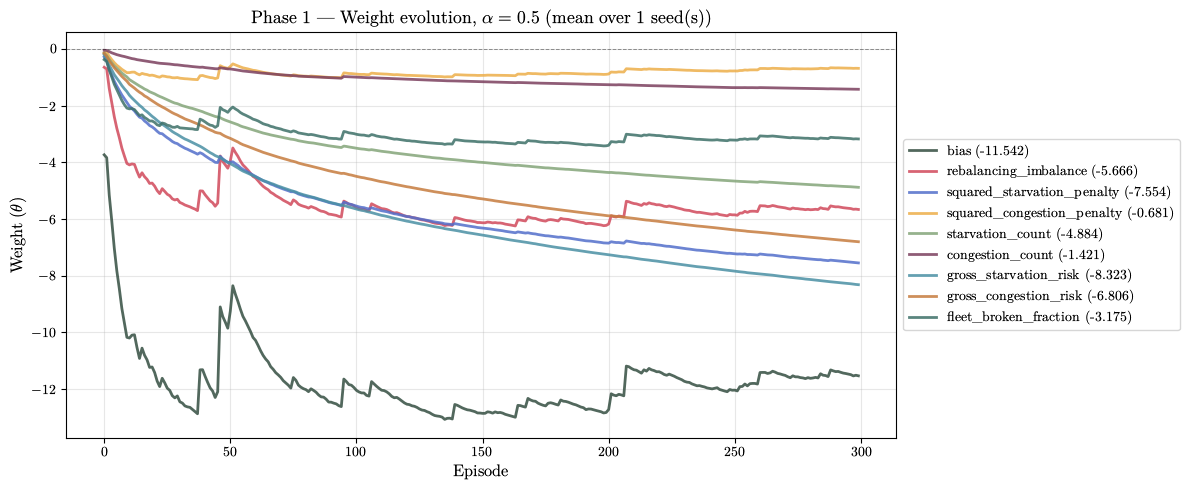

In [33]:
# ── Phase 1: Weight evolution per α ──────────────────────────────────────
for key in sorted(groups_alpha):
    runs = groups_alpha[key]
    try:
        v = float(key)
        title = rf"Phase 1 --- Weight evolution, $\alpha={v:g}$ (mean over {len(runs)} seed(s))"
    except ValueError:
        title = f"Phase 1 \u2014 Weight evolution, \u03b1={key}"
    fig = plot_weight_evolution(runs, title=title)
    if fig:
        plt.show()

In [34]:
# ── Phase 1: Convergence metrics table ───────────────────────────────────
convergence_table(groups_alpha, param_name=r"$\alpha$", last_n=PHASE1_LAST_N)

,N seeds,Peak SL,Final SL (mean),Convergence ep.,Final $\|\theta\|$,Rel. $\Delta\theta$ (%)
$\alpha$,,,,,,
0.005,1,0.9440,0.9414,0,3.628,0.05
0.01,1,0.9440,0.9415,0,4.676,0.06
0.05,1,0.9440,0.9412,0,9.961,0.08
0.1,1,0.9440,0.9422,0,11.878,0.11
0.5,1,0.9419,0.9399,0,19.162,0.26


In [35]:
# ── Phase 1: Lock α ──────────────────────────────────────────────────────
LOCKED_ALPHA = 0.1  # ← SET THIS after reviewing results above
print(f"Locked:  \u03b1 = {LOCKED_ALPHA}")

Locked:  α = 0.1


---
## Phase 2 — Discount Factor γ

**Before running this section**, train with the locked α:

```bash
python policies/sjovik_sund/ablation_study/run_ablation_study.py \
  --experiments EX15_FleetBrokenGlobal \
  --alphas 0.1 \
  --gammas 0.95 0.97 0.99 \
  --seeds 1000 \
  --episodes 300 \
  --output_dir tuning/phase2_gamma \
  --weight_starvation -1.0 \
  --weight_congestion -1.0 \
  --weight_fleet_degradation 0.0 \
  --use_bias_feature \
  --initial_bias -2.5 \
  --transition_update_interval 100 \
  --use_terminal_update \
  --use_feature_scale_diagnostics \
  --diagnostic_every_n_episodes 25 \
  --epsilon_start 0.0 \
  --epsilon_end 0.0
```

In [36]:
# ── Phase 2 config ────────────────────────────────────────────────────────
PHASE2_DIR    = "models/tuning/phase2_gamma"
PHASE2_LAST_N = 30

groups_gamma = load_training_runs(PHASE2_DIR, group_by="gamma", smooth_window=30)
print(f"Found {len(groups_gamma)} gamma group(s):")
for k, v in sorted(groups_gamma.items()):
    try:
        gval = _token_to_float(k)
        print(f"  \u03b3={gval:g}: {len(v)} seed(s)")
    except Exception:
        print(f"  key={k}: {len(v)} seed(s)")

Found 3 gamma group(s):
  γ=0.95: 1 seed(s)
  γ=0.97: 1 seed(s)
  γ=0.99: 1 seed(s)


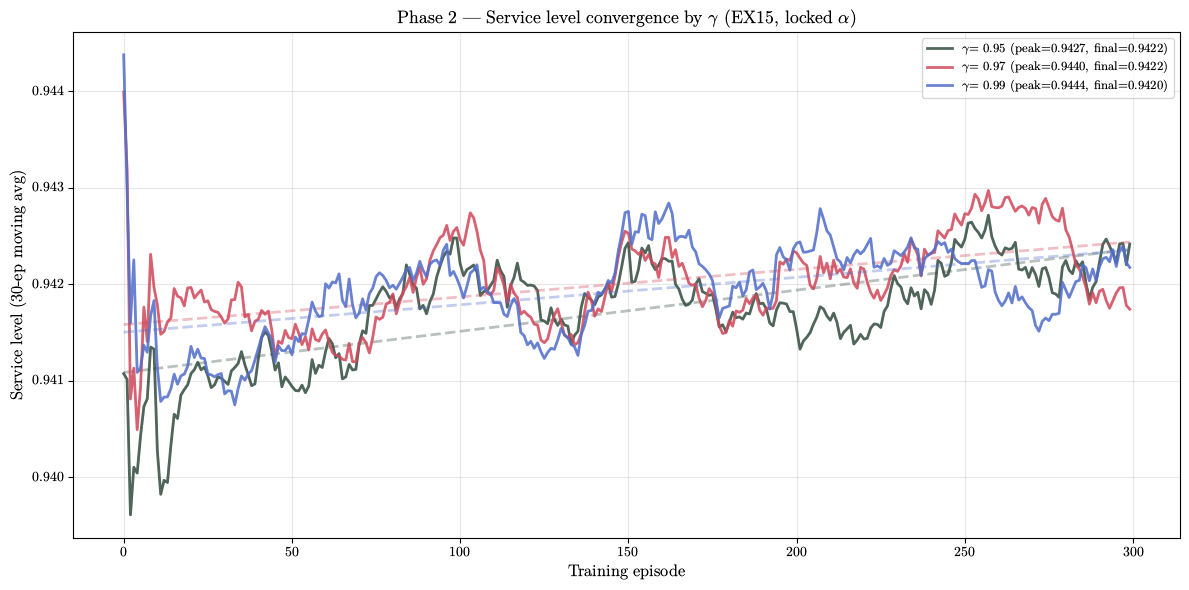

In [37]:
# ── Phase 2: SL convergence ───────────────────────────────────────────────
fig = plot_sl_comparison(
    groups_gamma,
    title=r"Phase 2 --- Service level convergence by $\gamma$ (EX15, locked $\alpha$)",
    param_label=r"$\gamma$",
    last_n=PHASE2_LAST_N,
)
plt.show()

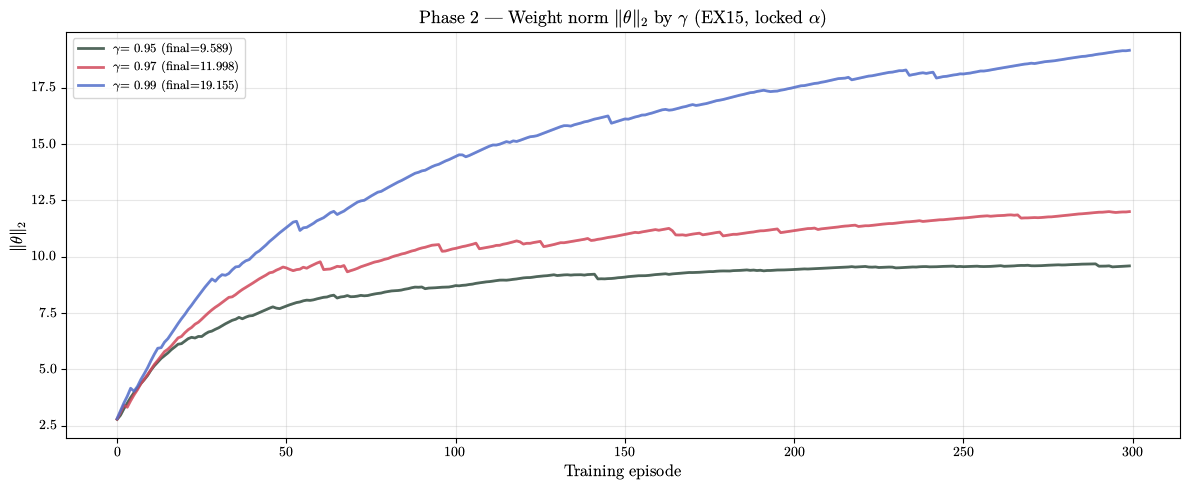

In [38]:
# ── Phase 2: Weight norm evolution ───────────────────────────────────────
fig = plot_norm_evolution(
    groups_gamma,
    title=r"Phase 2 --- Weight norm $\|\theta\|_2$ by $\gamma$ (EX15, locked $\alpha$)",
    param_label=r"$\gamma$",
)
plt.show()

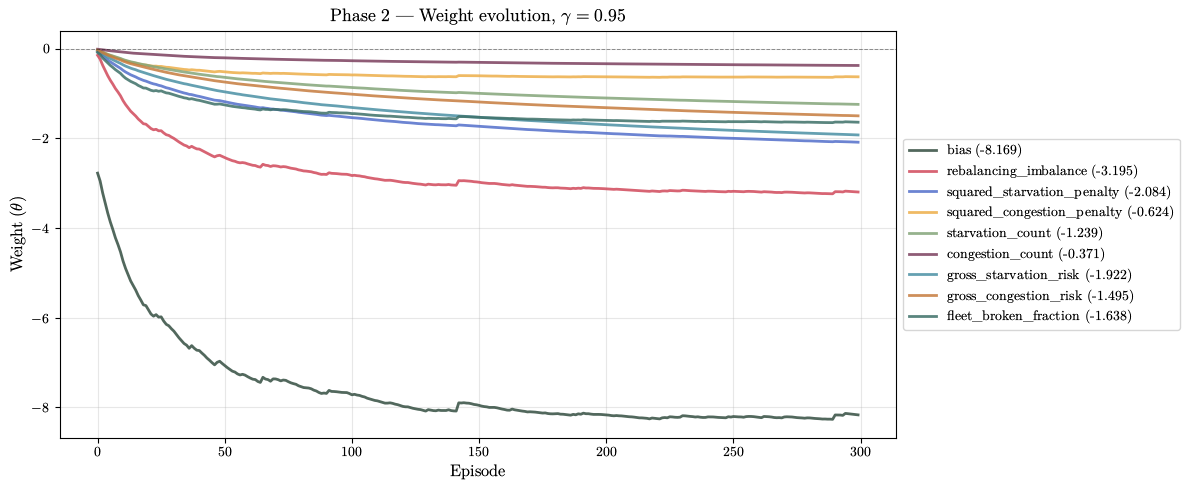

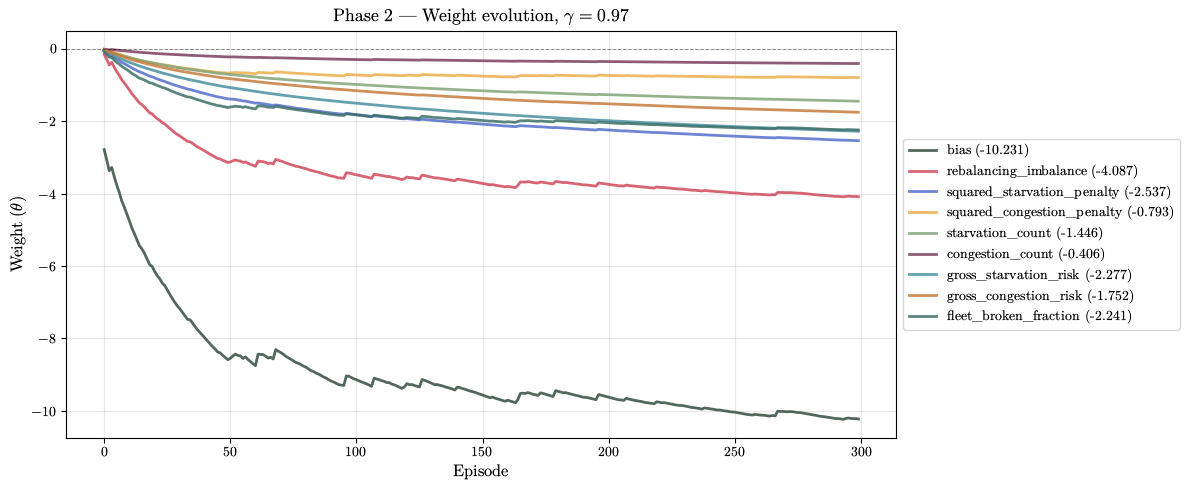

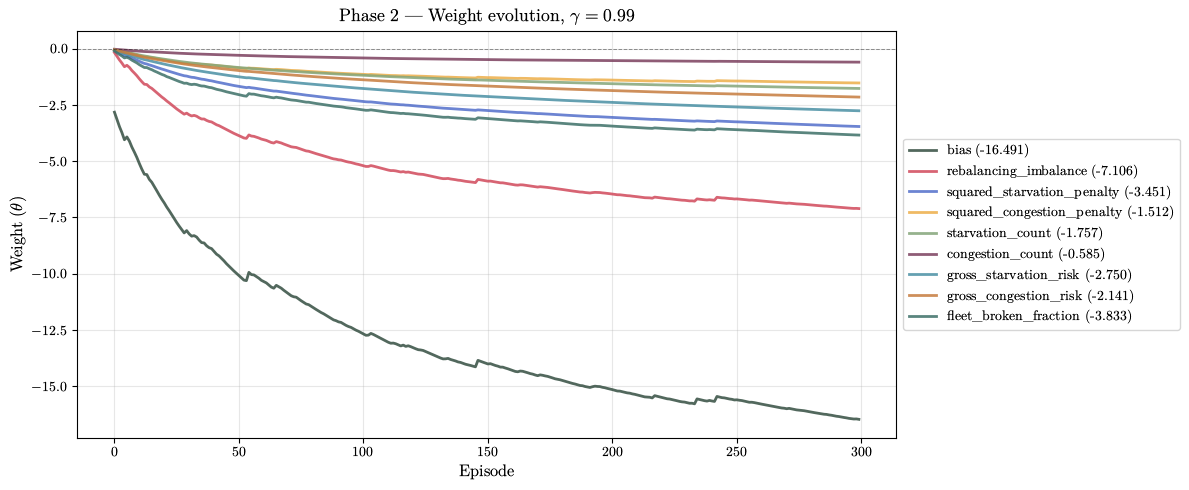

In [39]:
# ── Phase 2: Weight evolution per γ ──────────────────────────────────────
for key in sorted(groups_gamma):
    runs = groups_gamma[key]
    try:
        v = _token_to_float(key)
        title = rf"Phase 2 --- Weight evolution, $\gamma={v:g}$"
    except Exception:
        title = f"Phase 2 \u2014 Weight evolution, \u03b3={key}"
    fig = plot_weight_evolution(runs, title=title)
    if fig:
        plt.show()

In [40]:
# ── Phase 2: Convergence table ────────────────────────────────────────────
convergence_table(groups_gamma, param_name=r"$\gamma$", last_n=PHASE2_LAST_N)

,N seeds,Peak SL,Final SL (mean),Convergence ep.,Final $\|\theta\|$,Rel. $\Delta\theta$ (%)
$\gamma$,,,,,,
0p95,1,0.9427,0.9422,0,9.616,0.12
0p97,1,0.9440,0.9422,0,11.878,0.11
0p99,1,0.9444,0.9420,0,18.866,0.11


In [41]:
# ── Phase 2: Lock γ ───────────────────────────────────────────────────────
LOCKED_GAMMA = 0.97   # ← SET THIS after reviewing results above
print(f"Locked:  \u03b3 = {LOCKED_GAMMA}")

Locked:  γ = 0.97


---
## Phase 3 — Reward Weights (ws, wc)

Run three separate training jobs (one per variant), then evaluate each with
`run_simulation_ingvild.py --policy hybrid`.

```bash
# Variant A: equal weights (baseline)
python policies/sjovik_sund/ablation_study/run_ablation_study.py \
  --experiments EX15_FleetBrokenGlobal \
  --alphas 0.1 \
  --gammas 0.97 \
  --weight_starvation -1.0 \
  --weight_congestion -1.0 \
  --weight_fleet_degradation 0.0 \
  --seeds 1000 \
  --episodes 300 \
  --output_dir tuning/phase3_reward \
  --use_bias_feature \
  --initial_bias -2.5 \
  --transition_update_interval 100 \
  --use_terminal_update \
  --use_feature_scale_diagnostics \
  --diagnostic_every_n_episodes 25 \
  --epsilon_start 0.0 \
  --epsilon_end 0.0

# Variant B: starvation-downweighted  (change --weight_starvation -0.7)
# Variant C: congestion-downweighted  (change --weight_congestion -0.7)
```

Then evaluate each trained model:

```bash
python policies/sjovik_sund/run_simulation_ingvild.py \
  --policy hybrid --vfa-model <PKL_PATH> \
  --lookahead 60 --num-scenarios 5 --n-routing 5\
  --warmup-days 7 --duration 504 --nsims 10 --seed 42 \
  --log-files results daily decisions hourly
```

Point `PHASE3_RUN_LOGS` to the resulting run log folders below.

In [42]:
# ── Phase 3 config ────────────────────────────────────────────────────────
# Map run_log path → display label for each reward variant
PHASE3_RUN_LOGS = {
    "run_logs/tuning/phase3_ws-1.0_wc-1.0": r"ws=$-1.0$, wc=$-1.0$ (equal)",
    "run_logs/tuning/phase3_ws-0.7_wc-1.0": r"ws=$-0.7$, wc=$-1.0$ (starv. down)",
    "run_logs/tuning/phase3_ws-1.0_wc-0.7": r"ws=$-1.0$, wc=$-0.7$ (cong. down)",
}
PHASE3_METRICS = ["service_level", "starvations", "congestions", "functional_ratio_end"]

df3 = load_eval_results(list(PHASE3_RUN_LOGS.keys()), label_override=PHASE3_RUN_LOGS)
print(f"Loaded {len(df3)} seed rows from {df3['label'].nunique() if not df3.empty else 0} variants")
df3[["label", "seed", "service_level", "starvations", "congestions"]].head() if not df3.empty else print("No data yet.")

Loaded 30 seed rows from 3 variants


,label,seed,service_level,starvations,congestions
0,"ws=$-1.0$, wc=$-1.0$ (equal)",42,0.9494,2138,911
1,"ws=$-1.0$, wc=$-1.0$ (equal)",43,0.9506,2084,886
2,"ws=$-1.0$, wc=$-1.0$ (equal)",44,0.9470,2235,912
3,"ws=$-1.0$, wc=$-1.0$ (equal)",45,0.9471,2274,874
4,"ws=$-1.0$, wc=$-1.0$ (equal)",46,0.9524,1952,854


,Service level (mean),Service level (std),Starvations (mean),Starvations (std),Congestions (mean),Congestions (std),Func. ratio end (FR) (mean),Func. ratio end (FR) (std)
Label,,,,,,,,
"ws=$-0.7$, wc=$-1.0$ (starv. down)",0.9503,0.0022,2159.6,128.8,801.9,50.7,0.9753,0.0068
"ws=$-1.0$, wc=$-1.0$ (equal)",0.9498,0.0020,2117.9,122.9,872.3,37.7,0.9719,0.0087
"ws=$-1.0$, wc=$-0.7$ (cong. down)",0.9496,0.0026,2122.0,189.6,881.9,71.7,0.9713,0.0058


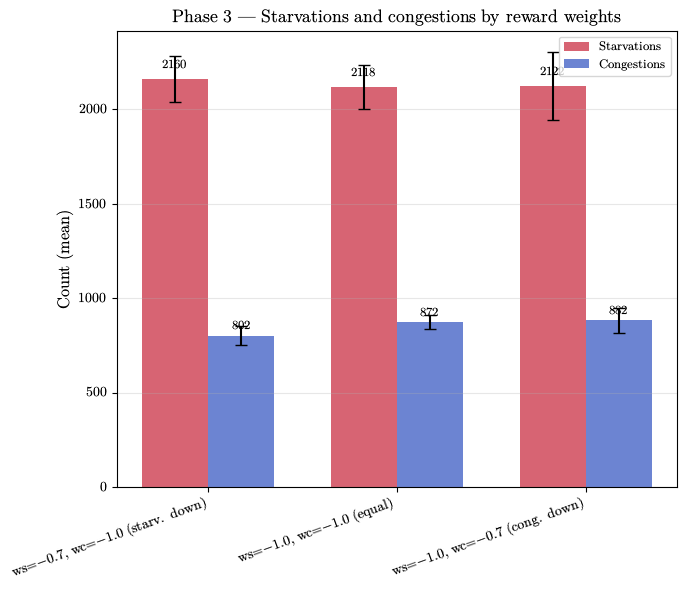

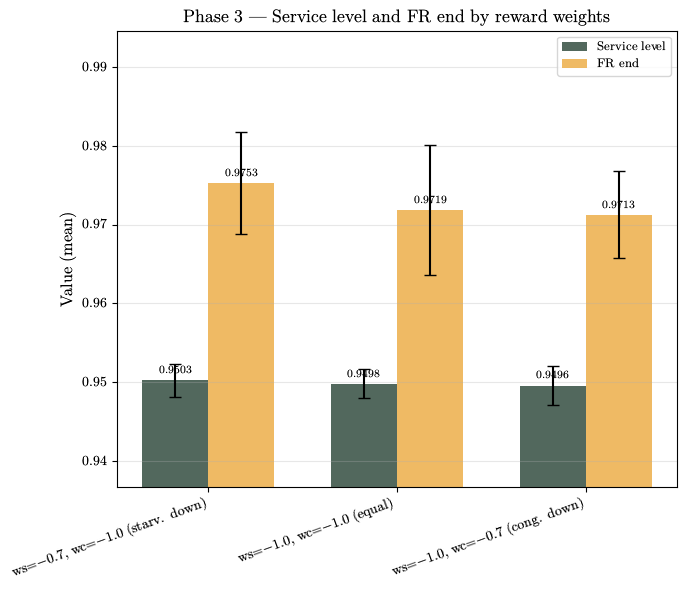

In [43]:
# -- Phase 3: Charts ------------------------------------------------
if not df3.empty:
    display(eval_summary_table(df3, PHASE3_METRICS, sort_by="service_level"))
    fig = plot_starv_cong_grouped(df3, title="Phase 3 — Starvations and congestions by reward weights")
    plt.show()
    fig = plot_sl_fr_grouped(df3, title="Phase 3 — Service level and FR end by reward weights")
    plt.show()
else:
    print("No data loaded yet — populate PHASE3_RUN_LOGS and re-run.")


In [44]:
# -- Phase 3: Load decisions data for hourly profile --
df3_dec = load_decisions_data(list(PHASE3_RUN_LOGS.keys()), label_override=PHASE3_RUN_LOGS)
print(f"Decisions rows: {len(df3_dec)} "
      f"from {df3_dec['label'].nunique() if not df3_dec.empty else 0} experiment(s)")


Decisions rows: 48166 from 3 experiment(s)


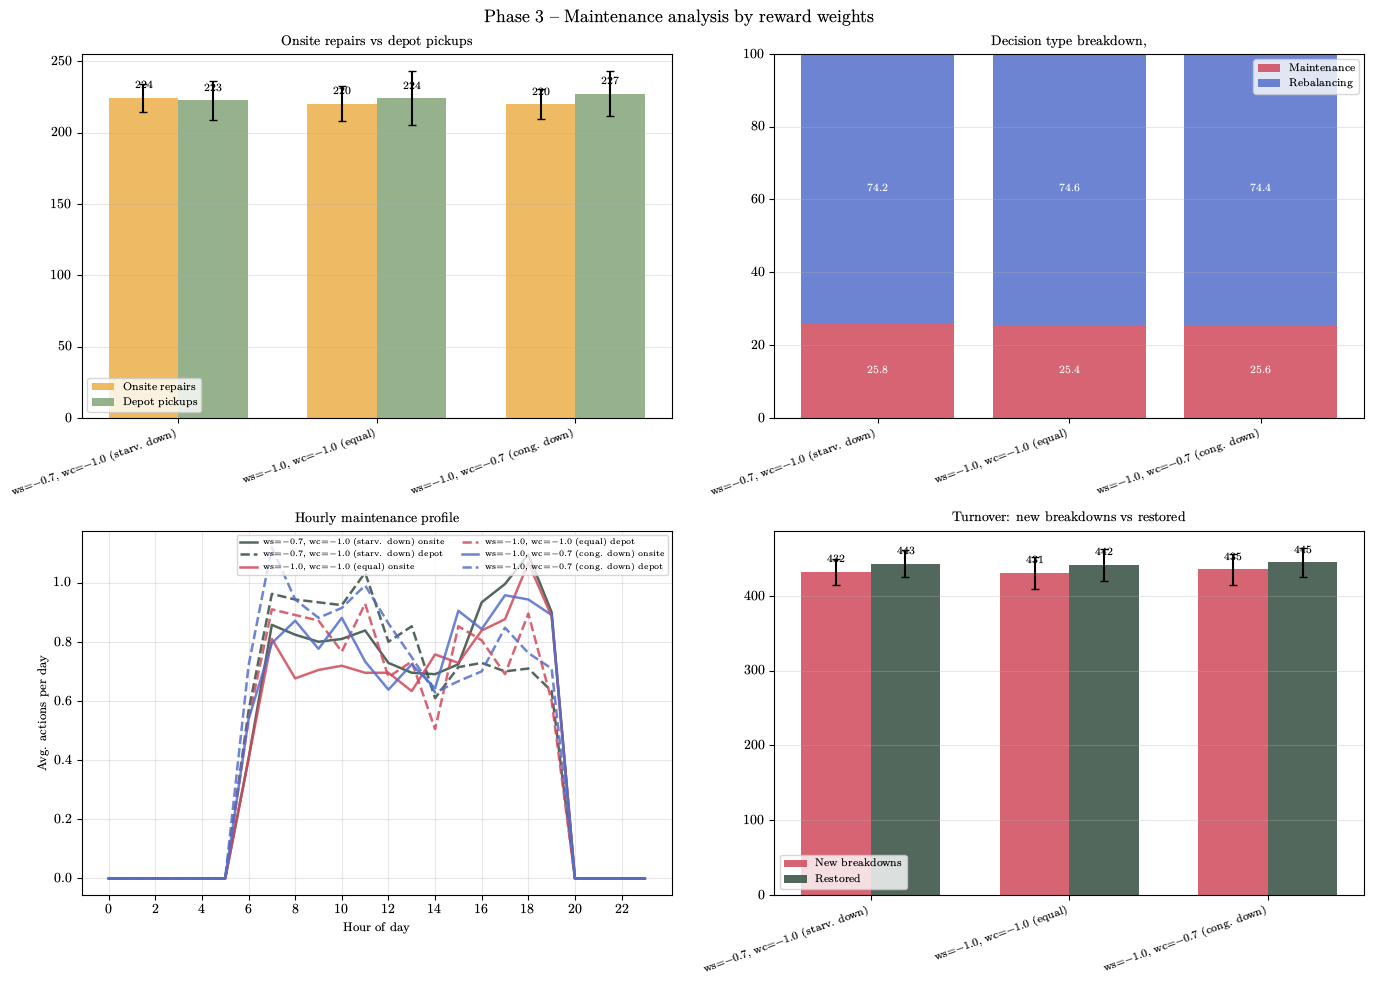

In [45]:
# -- Phase 3: Maintenance analysis grid ---------------
if not df3.empty:
    fig = plot_maintenance_grid(
        df3,
        df3_dec if not df3_dec.empty else None,
        title="Phase 3 -- Maintenance analysis by reward weights",
    )
    plt.show()
else:
    print("No data loaded yet.")


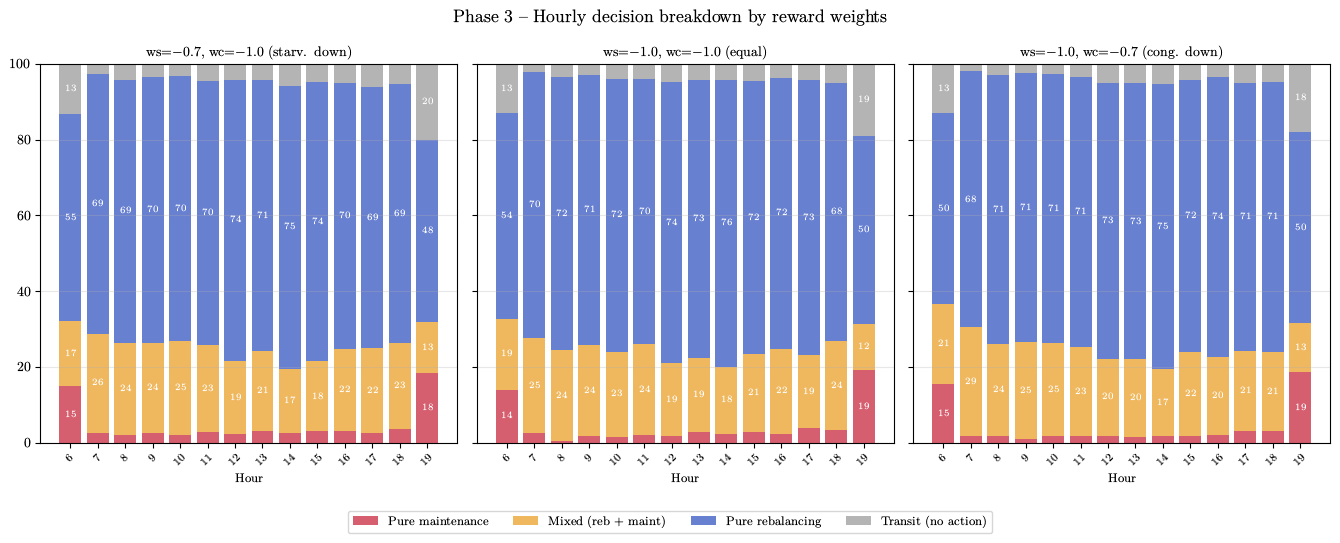

In [46]:
# -- Phase 3: Hourly decision breakdown (100% stacked bar) -----------
if not df3_dec.empty:
    fig = plot_hourly_decision_breakdown(
        df3_dec,
        df_results=df3,
        title="Phase 3 -- Hourly decision breakdown by reward weights",
    )
    plt.show()
else:
    print("No decisions data loaded yet.")


In [47]:
# ── Phase 3: Lock reward weights ──────────────────────────────────────────
LOCKED_WS = -1.0   # ← weight_starvation
LOCKED_WC = -1.0   # ← weight_congestion
print(f"Locked:  ws = {LOCKED_WS},  wc = {LOCKED_WC}")

Locked:  ws = -1.0,  wc = -1.0


---
## Phase 4 — Rollout Parameters (H, S, R)

Coordinate-descent evaluation with the locked trained VFA — no retraining.
Uses `run_simulation_ingvild.py`, which has all required flags and warmup support
(7-day warmup + 21-day evaluation = `--warmup-days 7 --duration 504`).

**Step 1**: vary H ∈ {30, 60, 90} min with S=5, R=5 fixed. Keep 5-minute analytical intervals by setting `--n-time-steps = H / 5` (30→6, 60→12, 90→18). Include decision logging so per-decision rollout runtime is recorded in each seed's `decisions.csv`.

```bash
# Template — run once per H value, changing both --lookahead and --n-time-steps
python policies/sjovik_sund/run_simulation_ingvild.py \
  --policy hybrid \
  --vfa-model <PATH_TO_LOCKED_VFA_PKL> \
  --lookahead 60 --n-time-steps 12 --num-scenarios 5 \ 
  --active-features bias rebalancing_imbalance squared_starvation_penalty squared_congestion_penalty starvation_count congestion_count gross_starvation_risk gross_congestion_risk fleet_broken_fraction \
  --lookahead 60 --n-time-steps 12 --num-scenarios 5 --n-routing 5 \
  --n-routing 5 \
  --warmup-days 7 --duration 504 \
  --nsims 10 --seed 42 \
  --log-files results daily decisions hourly
```

The run log folder is named `Hybrid_<exp>_H{H}_S{S}_R{R}_...` — point `PHASE4_RUN_LOGS` to it.

**Step 2**: fix best H, vary S ∈ {3, 5, 10} (change `--num-scenarios`).  
**Step 3**: fix best H + S, vary R ∈ {3, 5, 10} (change `--n-routing`).

In [48]:
# ── Phase 4 config ────────────────────────────────────────────────────────
# Each entry: run_log_path → display label.  Use consistent naming: H{h} S{s} R{r}
PHASE4_RUN_LOGS = {
    # Step 1 — vary H (S=5, R=5)
    "run_logs/tuning/phase4_H30_S5_R5":  "H=30, S=5, R=5",
    "run_logs/tuning/phase4_H60_S5_R5":  "H=60, S=5, R=5",
    "run_logs/tuning/phase4_H90_S5_R5":  "H=90, S=5, R=5",
    # Step 2 — vary S (uncomment after locking H)
    # "run_logs/tuning/phase4_H60_S3_R5":  "H=60, S=3, R=5",
    # "run_logs/tuning/phase4_H60_S10_R5": "H=60, S=10, R=5",
    # Step 3 — vary R (uncomment after locking H + S)
    # "run_logs/tuning/phase4_H60_S5_R3":  "H=60, S=5, R=3",
    # "run_logs/tuning/phase4_H60_S5_R10": "H=60, S=5, R=10",
}

# Metrics — add/remove columns here as needed
PHASE4_METRICS = [
    "service_level",
    "starvations",
    "congestions",
    "functional_ratio_end",   # FR: fleet functional ratio at end of simulation
    "maintenance_pct",        # (onsite_repairs + depot_pickups) / all maint+reb actions
    "avg_decision_runtime_s", # mean seconds per real rollout decision from decisions.csv
    "p95_decision_runtime_s", # p95 seconds per real rollout decision from decisions.csv
]

df4 = load_eval_results(list(PHASE4_RUN_LOGS.keys()), label_override=PHASE4_RUN_LOGS)
print(f"Loaded {len(df4)} seed rows from {df4['label'].nunique() if not df4.empty else 0} configs")
df4[["label", "seed", "service_level", "starvations", "congestions", "avg_decision_runtime_s", "p95_decision_runtime_s"]].head(10) if not df4.empty else print("No data yet.")

Loaded 0 seed rows from 0 configs
No data yet.


In [49]:
# ── Phase 4: Summary table ────────────────────────────────────────────────
if not df4.empty:
    display(eval_summary_table(df4, PHASE4_METRICS, sort_by="service_level"))
else:
    print("No data yet \u2014 populate PHASE4_RUN_LOGS and re-run.")

No data yet — populate PHASE4_RUN_LOGS and re-run.


In [50]:
# -- Phase 4: Bar charts --------------------------------------------
if not df4.empty:
    fig = plot_starv_cong_grouped(df4, title="Phase 4 — Starvations and congestions by rollout config")
    plt.show()
    fig = plot_sl_fr_grouped(df4, title="Phase 4 — Service level and FR end by rollout config")
    plt.show()


In [51]:
# ── Phase 4: Lock rollout parameters ─────────────────────────────────────
LOCKED_LOOKAHEAD  = 60   # minutes
LOCKED_SCENARIOS  = 5
LOCKED_ROUTING    = 5
print(f"Locked:  H = {LOCKED_LOOKAHEAD} min,  S = {LOCKED_SCENARIOS},  R = {LOCKED_ROUTING}")

Locked:  H = 60 min,  S = 5,  R = 5


---
## Final Configuration Summary

In [52]:
summary_config = pd.DataFrame([
    {"Parameter": r"Feature set",          "Value": "EX15 FleetBrokenGlobal",   "Phase": "\u2014"},
    {"Parameter": r"Learning rate \u03b1", "Value": str(LOCKED_ALPHA),           "Phase": "1"},
    {"Parameter": r"Discount factor \u03b3","Value": str(LOCKED_GAMMA),          "Phase": "2"},
    {"Parameter": r"Starvation weight ws", "Value": str(LOCKED_WS),              "Phase": "3"},
    {"Parameter": r"Congestion weight wc", "Value": str(LOCKED_WC),              "Phase": "3"},
    {"Parameter": r"Lookahead H (min)",    "Value": str(LOCKED_LOOKAHEAD),       "Phase": "4"},
    {"Parameter": r"Scenarios S",          "Value": str(LOCKED_SCENARIOS),       "Phase": "4"},
    {"Parameter": r"Routing candidates R", "Value": str(LOCKED_ROUTING),         "Phase": "4"},
]).set_index("Parameter")

summary_config.style.set_caption("Final tuned configuration \u2014 EX15 FleetBrokenGlobal")

,Value,Phase
Parameter,,
Feature set,EX15 FleetBrokenGlobal,—
Learning rate \u03b1,0.1,1
Discount factor \u03b3,0.97,2
Starvation weight ws,-1.0,3
Congestion weight wc,-1.0,3
Lookahead H (min),60,4
Scenarios S,5,4
Routing candidates R,5,4
